# (10) leapfrog

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>

Use leapfrog to fit vH16 w/ leared dt

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [3]:
from figures.analysis import plot_convergence
from figures.imgs import plot_weights


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Trainer

In [4]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('vH16', model_type, 'leapfrog|lin')
cfg_vae['seq_len'] = 10
cfg_vae['n_iters'] = 4

cfg_vae['track_stats'] = True

cfg_vae['beta_inner'] = 1.0
cfg_tr['kl_beta'] = 10.0

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'leapfrog', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.0001, 'seq_len': 10, 'n_iters': 4, 'track_stats': True, 
'beta_inner': 1.0}

Trainer:
{'batch_size': 200, 'epochs': 300, 'optimizer_kws': {'weight_decay': 0.0}, 'grad_clip': 200, 'kl_beta': 10.0}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.9 K   |
|     ———     |    ———     |
|    layer    |  132.9 K   |
+-------------+------------+

poisson_vH16_t-10×4_b-1_z-[512]_<leapfrog|lin>
b200-ep300-lr(0.002)_beta(10:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_10,11:11)

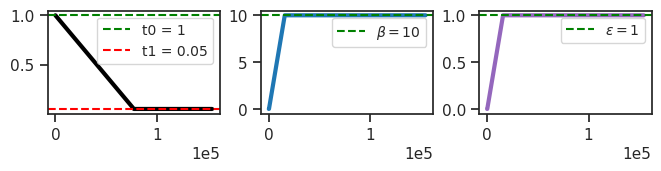

In [5]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [6]:
print(tr.model.layer)

PoissonLayer(input_dim=256,latent_dim=512, beta_inner=1, temp=1)

In [7]:
tr.model.layer.log_gamma, tr.model.layer.log_dt

(Parameter containing:
 tensor([0.], device='cuda:1', requires_grad=True),
 Parameter containing:
 tensor([0.], device='cuda:1', requires_grad=True))

In [8]:
tr.model.layer.log_bias.shape, tr.model.layer.log_lr

(torch.Size([1, 512]),
 Parameter containing:
 tensor([0.], device='cuda:1', requires_grad=True))

In [ ]:
cm = 'learned-dt'
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 45, avg loss: 154.957090:  15%|▉     | 45/300 [37:50<3:36:18, 50.90s/it]

In [ ]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

In [ ]:
fig, ax = create_figure()

kws = dict(stat='percent',  ax=ax)
sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', **kws)
# sns.histplot(tonp(tr.model.layer.log_lr.squeeze().exp()), label='lr', **kws)
ax.legend()
plt.show()

In [ ]:
log_scale = tonp(tr.model.layer.log_scale.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend();

In [ ]:
var = np.exp(log_scale) ** 2
var = var.reshape(16, 16)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar();

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar();

In [ ]:
kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

## output

In [ ]:
%%time

output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

print(list(output))

In [18]:
u_norm = torch.linalg.norm(output['u'], axis=-1)
r_norm = torch.linalg.norm(torch.exp(output['u']), axis=-1)
# v_norm = torch.linalg.norm(output['v'], axis=-1)
# a_norm = torch.linalg.norm(output['a'], axis=-1)

In [ ]:
plot(u_norm.mean(0), marker='o');

In [ ]:
plot(r_norm.mean(0));

In [21]:
# plot(v_norm.mean(0), marker='o');
# plot(a_norm.mean(0), marker='o');

In [ ]:
num = 20
n_timepoints = 50
x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()
# .reshape(tr.model.cfg.shape)

_ = plot_weights(x2p, nrows=num)

In [ ]:
num = 20
n_timepoints = 50
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()
# .reshape(tr.model.cfg.shape)

_ = plot_weights(x2p, nrows=num)